# Mid-Term Project: Multi-Constraint Portfolio Allocation

**Student Name:** [Mateo Zeppieri]
**Date:** [March 9, 2026]
**Chosen context:** [Professional Baseball – payroll allocation across player acquisitions]
**Field:** [Professional Baseball Analytics]

## Project Overview

You will choose a resource allocation problem in your field, create a synthetic dataset with **8–10 options**, build a **multi-constraint optimization model**, explore **near-optimal alternatives**, run deep sensitivity analysis and validation, then respond to **two stakeholder changes of mind**. The deliverable is one notebook with clear documentation and an executive summary suitable to hand off to a manager.

**Learning Objectives:**
- Build a multi-constraint continuous LP in PuLP (budget cap, category coverage, concentration cap)
- Diagnose and handle infeasibility when constraints interact
- Identify near-optimal alternative solutions and explain why they might be preferred
- Perform sensitivity analysis across 5 parameters at ±20% and ±40%
- Apply extreme value testing and one additional what-if scenario
- Validate the solution with sanity checks and a fragile vs. robust assessment
- Respond to two stakeholder changes of mind with updated models and a three-way comparison
- Communicate findings in an executive summary suitable for a non-technical decision-maker\

In [23]:
# Install required packages (if needed in Colab)
# Skip if running locally and packages are already installed
%pip install pulp pandas matplotlib numpy -q

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpMaximize, LpMinimize, LpProblem, LpVariable, lpSum, value, LpStatus, PULP_CBC_CMD
import io

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Creating Your Synthetic Dataset

Your dataset must have **8–10 rows** (one row per option) and **4 columns**:

1. **option** — a name or label for each option (e.g. "Channel_A", "Program_ICU")
2. **category** — which of exactly **3 logical groups** this option belongs to (e.g. "Paid", "Organic", "Brand"). Every option must belong to one group. You must have at least one option per group.
3. **benefit_rate** — the expected return per unit allocated. This is the coefficient in your objective function. Use a decimal (e.g. 0.04 = 4 cents returned per dollar spent).
4. **[your_field_column]** — one additional numeric attribute meaningful in your field (e.g. `quality_score`, `risk_rating`, `reach_index`). Rename this column to match your context.

You will also set **three global constraint values** in your code (not in the CSV):

- `budget_total` — total resource available (e.g. $50,000 or 2,000 staff-hours)
- `min_alloc_per_category` — minimum each of the 3 categories must receive (ensures balanced portfolio)
- `concentration_cap` — maximum fraction any single option can receive (e.g. 0.35 = no option gets more than 35% of the total budget)

**Feasibility check before you start:** Confirm that `min_alloc_per_category × 3 < budget_total` and `concentration_cap × budget_total > min_alloc_per_category`. If not, your model will be infeasible immediately — adjust the values.

**Step-by-step LLM prompt:**

1. Open a **new** conversation with ChatGPT, Claude, or Copilot.
2. Say: "I need a synthetic dataset for a prescriptive analytics portfolio allocation problem. I will use Python with pandas and PuLP. I need the output as **CSV only**."
3. Tell it your field: "I am modeling [your decision, e.g. 'marketing ad spend across channels']."
4. Say: "Create a CSV with **exactly [8, 9, or 10] rows** and these exact columns: `option` (name), `category` (one of exactly 3 groups — use these names: [name your 3 groups]), `benefit_rate` (decimal, e.g. 0.02 to 0.09, realistic for my context), `[your_field_column]` (numeric, realistic). Use realistic but simple numbers. Also give me three constraint values: `budget_total`, `min_alloc_per_category`, `concentration_cap`. Output only the CSV and the three values; no other text."
5. Copy the CSV and paste it below. Set the three constraint values in the code cell.

In [25]:
# Paste your CSV here and set the three constraint values.
# Paste your CSV here and set the three constraint values.

csv_string = """
option,category,benefit_rate,scouting_grade
Player_A,Position Players,0.085,60
Player_B,Position Players,0.072,55
Player_C,Position Players,0.061,50
Player_D,Starting Pitchers,0.093,65
Player_E,Starting Pitchers,0.074,58
Player_F,Starting Pitchers,0.057,52
Player_G,Relief Pitchers,0.081,59
Player_H,Relief Pitchers,0.066,54
Player_I,Relief Pitchers,0.049,48
"""

options_df = pd.read_csv(io.StringIO(csv_string.strip()))

# Three global constraint values
budget_total           = 120   # Total payroll available (in millions)
min_alloc_per_category = 25    # Each category must receive at least this much
concentration_cap      = 0.35  # No single option gets more than this fraction of budget_total

# Derived check value (used later)
max_single_alloc = concentration_cap * budget_total

# ── Display ────────────────────────────────────────────────────────────────────
print(options_df.to_string(index=False))
print(f"\nNumber of options: {len(options_df)}")
print(f"Number of categories: {options_df['category'].nunique()} — {list(options_df['category'].unique())}")
print(f"\nConstraint values:")
print(f"  budget_total           = {budget_total:,}")
print(f"  min_alloc_per_category = {min_alloc_per_category:,}")
print(f"  concentration_cap      = {concentration_cap} (max single option = {max_single_alloc:,.0f})")

# Quick feasibility pre-check
feasibility_ok = (min_alloc_per_category * 3 < budget_total) and (max_single_alloc >= min_alloc_per_category)
print(f"\nPre-check: {'✓ Constraint values look feasible' if feasibility_ok else '⚠ WARNING: constraint values may cause immediate infeasibility — adjust before proceeding'}")

  option          category  benefit_rate  scouting_grade
Player_A  Position Players         0.085              60
Player_B  Position Players         0.072              55
Player_C  Position Players         0.061              50
Player_D Starting Pitchers         0.093              65
Player_E Starting Pitchers         0.074              58
Player_F Starting Pitchers         0.057              52
Player_G   Relief Pitchers         0.081              59
Player_H   Relief Pitchers         0.066              54
Player_I   Relief Pitchers         0.049              48

Number of options: 9
Number of categories: 3 — ['Position Players', 'Starting Pitchers', 'Relief Pitchers']

Constraint values:
  budget_total           = 120
  min_alloc_per_category = 25
  concentration_cap      = 0.35 (max single option = 42)

Pre-check: ✓ Constraint values look feasible


**Data documentation :** In one sentence, state that you used a language model to generate this data, and describe what it contains (number of options, category names, constraint names and values).

I used a language model to generate a synthetic dataset with 9 professional baseball player options across Position Players, Starting Pitchers, and Relief Pitchers, along with constraint values of budget_total = 120, min_alloc_per_category = 25, and concentration_cap = 0.35.

---
## Part 1: Problem Framing and Dataset

### 1.1 Decision Statement

**Instructions:** Write a clear decision statement in the form: "I need to decide how to allocate [resource] across [options], subject to [constraints], in order to [objective]."

**Your Decision Statement:**
I need to decide how to allocate a fixed payroll budget across potential professional baseball player acquisitions, subject to budget, category coverage, and concentration constraints, in order to maximize expected team performance measured by projected wins added.

### 1.2 Decision Variables vs Inputs

**Instructions:** List your decision variables (what the model determines) and your inputs (what you provide). Briefly explain why each belongs in its category. Note that all decision variables in this model are **continuous** (any non-negative value).

**Decision Variables (what the model decides):**
The payroll allocated to each of the 9 player options (alloc_Player_A through alloc_Player_I), measured in millions of dollars.

**Inputs (what you provide to the model):**
The benefit_rate for each player option, category assignment (Position Players, Starting Pitchers, Relief Pitchers), scouting_grade for each option, and the global constraint values including budget_total, min_alloc_per_category, and concentration_cap.

**Explanation:**
Decision variables are determined by the optimization model and represent how payroll is allocated across options, while inputs are fixed values provided to the model that define expected performance, structure the constraints, and guide the allocation decision.

### 1.3 Objectives and Constraints

**Instructions:** State your objective and all three constraints. For each constraint, label it **hard** and explain in one sentence what happens in the real world if it is violated.

**Objective:**
Maximize total expected team performance measured as the sum of (benefit_rate × payroll allocation) across all player options.

**Constraint 1 — Budget Cap (hard):**
Total payroll allocated across all player options cannot exceed the available payroll budget (120 million dollars) because teams must stay within financial limits set by ownership and league payroll structures.

**Constraint 2 — Category Coverage (hard):**
Each roster category (Position Players, Starting Pitchers, Relief Pitchers) must receive at least 25 million dollars because a competitive team requires balanced investment across key roster areas.

**Constraint 3 — Concentration Cap (hard):**
No single player option may receive more than 35% of the total payroll budget because allocating too much payroll to one player increases financial risk and reduces roster flexibility.

### 1.4 Key Parameters and Uncertainty

**What are the "five parameters"?** They are the inputs you will vary in sensitivity analysis:

- **Parameter 1:** `benefit_rate` for all options (shift every option’s rate by the same percentage).
- **Parameter 2:** `benefit_rate` for the **top option only** — the single option with the highest `benefit_rate` in your dataset. This represents uncertainty in your best option’s return; the code will vary only this option’s rate.
- **Parameters 3–5:** The three global constraint values (`budget_total`, `min_alloc_per_category`, `concentration_cap`).

Your dataset’s fourth column (e.g. `quality_score`, `risk_rating`) is still used for context and can appear in this table as supporting documentation, but the second *sensitivity* parameter is always benefit_rate (top option only) so that all five parameters affect the objective.

**Instructions:** Complete the table below for all 5 parameters.

| # | Parameter | Source | Why it might differ from reality | Estimated uncertainty |
| # | Parameter                      | Source                                                       | Why it might differ from reality                                                          | Estimated uncertainty |
| - | ------------------------------ | ------------------------------------------------------------ | ----------------------------------------------------------------------------------------- | --------------------- |
| 1 | benefit_rate (all options)     | Historical player performance data and projections           | Player performance can vary due to injuries, aging, role changes, or team fit             | ±25%                  |
| 2 | benefit_rate (top option only) | Advanced projections and scouting reports for the top player | The top option carries higher uncertainty due to expectations, pressure, and injury risk  | ±30%                  |
| 3 | budget_total                   | Team payroll planning and ownership financial limits         | Ownership decisions, revenue changes, or luxury tax considerations may shift payroll      | ±20%                  |
| 4 | min_alloc_per_category         | Roster construction strategy and team needs                  | Injuries, trades, or performance gaps may require reallocating resources across positions | ±20%                  |
| 5 | concentration_cap              | Front office risk management strategy                        | Teams may adjust risk tolerance depending on competitive window or market opportunities   | ±15%                  |



---
## Part 2: Optimization Model and Near-Optimal Exploration

### 2.1 Build and Solve the Base Model

**Instructions:** The code below builds a multi-constraint LP with your three constraints. Adapt the column name `'benefit_rate'` if yours is named differently. Run the cell and check the Status before interpreting results.

In [26]:
# ── Base model setup ──────────────────────────────────────────────────────────
n          = len(options_df)
categories = options_df['category'].unique()
benefit_col = 'benefit_rate'

model_base = LpProblem("Portfolio_Base", LpMaximize)

# Decision variables: how much to allocate to each option (continuous, ≥ 0)
alloc = [LpVariable(f"alloc_{i}", lowBound=0) for i in range(n)]

# ── Objective ──────────────────────────────────────────────────────────────────
model_base += lpSum([alloc[i] * options_df.iloc[i][benefit_col]
                     for i in range(n)]), "Total_Benefit"

# ── Constraint 1: Budget cap ───────────────────────────────────────────────────
model_base += lpSum(alloc) <= budget_total, "Budget_Cap"

# ── Constraint 2: Category coverage ───────────────────────────────────────────
# Each category must receive at least min_alloc_per_category
for cat in categories:
    cat_idx = options_df.index[options_df['category'] == cat].tolist()
    model_base += (lpSum([alloc[i] for i in cat_idx]) >= min_alloc_per_category,
                   f"Coverage_{cat}")

# ── Constraint 3: Concentration cap ───────────────────────────────────────────
# No single option may receive more than concentration_cap × budget_total
for i in range(n):
    model_base += (alloc[i] <= concentration_cap * budget_total,
                   f"Cap_{options_df.iloc[i, 0]}")

# ── Solve ──────────────────────────────────────────────────────────────────────
model_base.solve(PULP_CBC_CMD(msg=0))

# ── Results ───────────────────────────────────────────────────────────────────
print(f"Status: {LpStatus[model_base.status]}")
print()

if model_base.status == 1:   # Optimal
    base_allocs = [value(alloc[i]) for i in range(n)]
    base_obj    = value(model_base.objective)

    print(f"Objective (total benefit): {base_obj:.4f}")
    print(f"Total allocated: {sum(base_allocs):,.2f}  /  budget: {budget_total:,}")
    print()
    print(f"{'Option':<20} {'Category':<12} {'Allocated':>12} {'% of budget':>12}")
    print("-" * 60)
    for i in range(n):
        opt  = options_df.iloc[i, 0]
        cat  = options_df.iloc[i]['category']
        alloc_val = base_allocs[i]
        pct  = 100 * alloc_val / budget_total
        print(f"{opt:<20} {cat:<12} {alloc_val:>12,.2f} {pct:>11.1f}%")
    print()
    print("Category totals:")
    for cat in categories:
        cat_idx   = options_df.index[options_df['category'] == cat].tolist()
        cat_total = sum(base_allocs[i] for i in cat_idx)
        print(f"  {cat}: {cat_total:,.2f}  (min required: {min_alloc_per_category:,})")

elif model_base.status == -1:  # Infeasible
    print("⚠ INFEASIBLE — see Section 2.2 below for diagnosis and how to relax.")
else:
    print(f"Solver returned status: {LpStatus[model_base.status]}")

Status: Optimal

Objective (total benefit): 10.3920
Total allocated: 120.00  /  budget: 120

Option               Category        Allocated  % of budget
------------------------------------------------------------
Player_A             Position Players        42.00        35.0%
Player_B             Position Players         0.00         0.0%
Player_C             Position Players         0.00         0.0%
Player_D             Starting Pitchers        42.00        35.0%
Player_E             Starting Pitchers         0.00         0.0%
Player_F             Starting Pitchers         0.00         0.0%
Player_G             Relief Pitchers        36.00        30.0%
Player_H             Relief Pitchers         0.00         0.0%
Player_I             Relief Pitchers         0.00         0.0%

Category totals:
  Position Players: 42.00  (min required: 25)
  Starting Pitchers: 42.00  (min required: 25)
  Relief Pitchers: 36.00  (min required: 25)


### 2.2 Feasibility Check and Interpretation

**Instructions:** Check the Status from the cell above.

- If **Optimal**: interpret the solution in 3–4 sentences. Which options received the most? Which category is closest to its minimum? Does the solution make intuitive sense?
- If **Infeasible**: diagnose which constraints interact to cause infeasibility (e.g. "The category coverage minimum of $X combined with the concentration cap of Y% leaves no feasible room for..."). Then go back and relax **one** constraint value in Section 0 (Loading Data), re-run the model, and document your reasoning below.

**Status:** Optimal

**Interpretation or infeasibility diagnosis:**
The model allocates the largest shares of payroll to Player_A and Player_D, each receiving the maximum allowed under the concentration cap because they provide the highest expected performance returns. Player_G receives the remaining budget and helps satisfy the category coverage requirement for relief pitching. The Relief Pitchers category is closest to its minimum allocation compared to the others. Overall, the solution makes intuitive sense because the model prioritizes the most efficient players while still maintaining balanced roster investment across all three categories.

**If you relaxed a constraint:** State which one, what value you changed it to, and why that relaxation is defensible in your field.


### 2.3 Near-Optimal Alternative 1

**Instructions:** Find an alternative solution within 5–10% of the base optimal objective by adding one additional constraint that forces a different allocation. The most straightforward approach: cap the top-allocated option at 70% of its base value. Re-solve and compare.

The purpose: demonstrate that **multiple good solutions exist** (Lesson 3) and that the "optimal" is not the only defensible recommendation.

In [27]:
# ── Identify the top-allocated option from the base solution ──────────────────
if model_base.status == 1:
    base_allocs  = [value(alloc[i]) for i in range(n)]
    top_idx      = int(np.argmax(base_allocs))
    top_val      = base_allocs[top_idx]
    top_name     = options_df.iloc[top_idx, 0]
    print(f"Top-allocated option in base solution: {top_name}  (${top_val:,.2f})")
    print(f"Capping it at 70% of that value: ${0.70 * top_val:,.2f}")
    print()

    # ── Alternative 1: cap the top option at 70% of its base allocation ────────
    model_alt1   = LpProblem("Portfolio_Alt1", LpMaximize)
    alloc_alt1   = [LpVariable(f"a1_{i}", lowBound=0) for i in range(n)]

    model_alt1  += lpSum([alloc_alt1[i] * options_df.iloc[i][benefit_col]
                          for i in range(n)]), "Total_Benefit"
    model_alt1  += lpSum(alloc_alt1) <= budget_total, "Budget_Cap"
    for cat in categories:
        cat_idx  = options_df.index[options_df['category'] == cat].tolist()
        model_alt1 += (lpSum([alloc_alt1[i] for i in cat_idx]) >= min_alloc_per_category,
                       f"Coverage_{cat}")
    for i in range(n):
        model_alt1 += (alloc_alt1[i] <= concentration_cap * budget_total, f"Cap_{i}")

    # The new constraint: limit the top option
    model_alt1  += alloc_alt1[top_idx] <= 0.70 * top_val, "Alt1_Limit_Top"

    model_alt1.solve(PULP_CBC_CMD(msg=0))
    print(f"Alt 1 Status: {LpStatus[model_alt1.status]}")

    if model_alt1.status == 1:
        alt1_allocs = [value(alloc_alt1[i]) for i in range(n)]
        alt1_obj    = value(model_alt1.objective)
        gap_pct     = 100 * (base_obj - alt1_obj) / base_obj

        print(f"Alt 1 Objective: {alt1_obj:.4f}  (gap from base: {gap_pct:.1f}%)")
        print()
        print(f"{'Option':<20} {'Base':>12} {'Alt 1':>12} {'Δ':>10}")
        print("-" * 58)
        for i in range(n):
            delta = alt1_allocs[i] - base_allocs[i]
            print(f"{options_df.iloc[i,0]:<20} {base_allocs[i]:>12,.2f} "
                  f"{alt1_allocs[i]:>12,.2f} {delta:>+10,.2f}")
    else:
        print("Alt 1 is infeasible with this cap — try a less restrictive limit (e.g. 0.80 instead of 0.70).")
else:
    print("Fix infeasibility in Section 2.1 before running this cell.")

Top-allocated option in base solution: Player_A  ($42.00)
Capping it at 70% of that value: $29.40

Alt 1 Status: Optimal
Alt 1 Objective: 10.2954  (gap from base: 0.9%)

Option                       Base        Alt 1          Δ
----------------------------------------------------------
Player_A                    42.00        29.40     -12.60
Player_B                     0.00         0.00      +0.00
Player_C                     0.00         0.00      +0.00
Player_D                    42.00        42.00      +0.00
Player_E                     0.00         6.60      +6.60
Player_F                     0.00         0.00      +0.00
Player_G                    36.00        42.00      +6.00
Player_H                     0.00         0.00      +0.00
Player_I                     0.00         0.00      +0.00


### 2.4 Near-Optimal Alternative 2

**Instructions:** Find a second alternative by adding a different constraint. Suggested approach: impose a maximum on the *second*-highest allocated option from the base solution (e.g. cap it at 70% of its base value), starting from the original base constraints (not Alt 1). Re-solve and compare.

In [28]:
# ── Alternative 2: cap the second-highest option ──────────────────────────────
if model_base.status == 1:
    sorted_idx    = sorted(range(n), key=lambda i: base_allocs[i], reverse=True)
    second_idx    = sorted_idx[1]   # second-highest in base solution
    second_val    = base_allocs[second_idx]
    second_name   = options_df.iloc[second_idx, 0]
    print(f"Second-highest option in base: {second_name}  (${second_val:,.2f})")
    print(f"Capping it at 70% of that value: ${0.70 * second_val:,.2f}")
    print()

    model_alt2    = LpProblem("Portfolio_Alt2", LpMaximize)
    alloc_alt2    = [LpVariable(f"a2_{i}", lowBound=0) for i in range(n)]

    model_alt2   += lpSum([alloc_alt2[i] * options_df.iloc[i][benefit_col]
                           for i in range(n)]), "Total_Benefit"
    model_alt2   += lpSum(alloc_alt2) <= budget_total, "Budget_Cap"
    for cat in categories:
        cat_idx   = options_df.index[options_df['category'] == cat].tolist()
        model_alt2 += (lpSum([alloc_alt2[i] for i in cat_idx]) >= min_alloc_per_category,
                       f"Coverage_{cat}")
    for i in range(n):
        model_alt2 += (alloc_alt2[i] <= concentration_cap * budget_total, f"Cap_{i}")

    # The new constraint: limit the second-highest option
    model_alt2   += alloc_alt2[second_idx] <= 0.70 * second_val, "Alt2_Limit_Second"

    model_alt2.solve(PULP_CBC_CMD(msg=0))
    print(f"Alt 2 Status: {LpStatus[model_alt2.status]}")

    if model_alt2.status == 1:
        alt2_allocs = [value(alloc_alt2[i]) for i in range(n)]
        alt2_obj    = value(model_alt2.objective)
        gap_pct2    = 100 * (base_obj - alt2_obj) / base_obj

        print(f"Alt 2 Objective: {alt2_obj:.4f}  (gap from base: {gap_pct2:.1f}%)")
        print()
        print(f"{'Option':<20} {'Base':>12} {'Alt 1':>12} {'Alt 2':>12}")
        print("-" * 60)
        for i in range(n):
            print(f"{options_df.iloc[i,0]:<20} {base_allocs[i]:>12,.2f} "
                  f"{alt1_allocs[i]:>12,.2f} {alt2_allocs[i]:>12,.2f}")
else:
    print("Fix infeasibility in Section 2.1 before running this cell.")

Second-highest option in base: Player_D  ($42.00)
Capping it at 70% of that value: $29.40

Alt 2 Status: Optimal
Alt 2 Objective: 10.1946  (gap from base: 1.9%)

Option                       Base        Alt 1        Alt 2
------------------------------------------------------------
Player_A                    42.00        29.40        42.00
Player_B                     0.00         0.00         0.00
Player_C                     0.00         0.00         0.00
Player_D                    42.00        42.00        29.40
Player_E                     0.00         6.60         6.60
Player_F                     0.00         0.00         0.00
Player_G                    36.00        42.00        42.00
Player_H                     0.00         0.00         0.00
Player_I                     0.00         0.00         0.00


### 2.5 Alternative Comparison and Interpretation

**Instructions:** Compare the three solutions (base, Alt 1, Alt 2). For each alternative, explain in 2–3 sentences: what changed, what was sacrificed in objective value, and why a real stakeholder or decision-maker might actually prefer that alternative over the mathematically optimal base solution.

**Base vs. Alt 1:**
Compared to the base solution, Alt 1 reduces payroll allocated to Player_A and redistributes those resources to Player_E and Player_G. This results in only a small sacrifice in objective value (0.9%) while creating a more balanced roster investment. A stakeholder might prefer Alt 1 because it reduces financial risk tied to one player and improves roster depth without meaningfully lowering projected performance.

**Base vs. Alt 2:**
Relative to the base solution, Alt 2 lowers payroll for Player_D and reallocates spending toward Player_E and Player_G. The tradeoff is a slightly larger but still modest drop in expected performance (1.9%). A stakeholder might prefer Alt 2 because it reduces dependence on a single starting pitcher and spreads risk more evenly across multiple roster areas.

**Key insight from near-optimal exploration:**
These results show that multiple strong solutions exist with only small performance differences, indicating the base recommendation is robust. This suggests decision-makers can adjust allocations based on strategic priorities without significantly sacrificing expected outcomes.

### 2.6 Base Solution Visualization

**Instructions:** Create a bar chart of the base solution allocation by option, color-coded by category. Give it a clear title and labeled axes. Reference this chart in your executive summary.

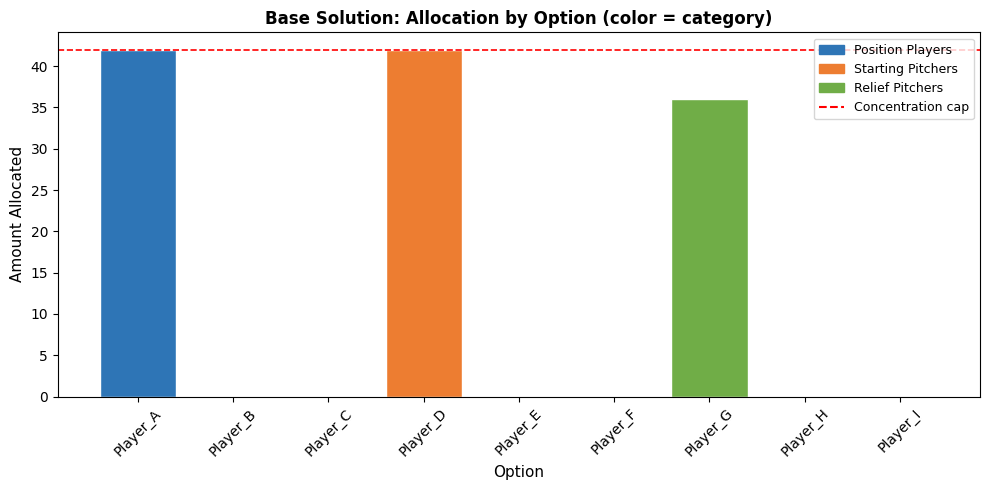

Figure 1: Base solution allocation by option.


In [29]:
# ── Base solution visualization ───────────────────────────────────────────────
if model_base.status == 1:
    fig, ax = plt.subplots(figsize=(10, 5))

    # Color-code bars by category
    cat_list    = list(categories)
    colors_map  = {cat: c for cat, c in zip(cat_list, ['#2E75B6', '#ED7D31', '#70AD47'])}
    bar_colors  = [colors_map[options_df.iloc[i]['category']] for i in range(n)]

    bars = ax.bar(options_df.iloc[:, 0], base_allocs, color=bar_colors, edgecolor='white')

    # Annotation: concentration cap line
    ax.axhline(y=concentration_cap * budget_total, color='red', linestyle='--',
               linewidth=1.2, label=f'Concentration cap ({concentration_cap*100:.0f}% of budget)')

    # Legend for categories
    handles = [plt.Rectangle((0,0),1,1, color=colors_map[c]) for c in cat_list]
    ax.legend(handles + [plt.Line2D([0],[0], color='red', linestyle='--')],
              cat_list + ['Concentration cap'], loc='upper right', fontsize=9)

    ax.set_xlabel("Option", fontsize=11)
    ax.set_ylabel("Amount Allocated", fontsize=11)
    ax.set_title("Base Solution: Allocation by Option (color = category)", fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    print("Figure 1: Base solution allocation by option.")
else:
    print("Resolve infeasibility in Section 2.1 before visualizing.")

---
## Part 3: Sensitivity Analysis and Validation

### 3.1 Sensitivity Analysis — 5 Parameters at ±20% and ±40%

**Instructions:** For each of your 5 key parameters (from Section 1.4), vary it at −40%, −20%, +20%, and +40% from its base value while holding all other parameters fixed. Record the objective value for each run. The code structure below tests all parameters in a loop — adapt the parameter names to match yours.

**The 5 parameters to test:**
1. `benefit_rate` — shift all options' rates by the same percentage
2. `benefit_rate` (top option only) — vary only the rate for the option with the highest benefit_rate in your dataset
3. `budget_total`
4. `min_alloc_per_category`
5. `concentration_cap`

In [30]:
# ── Sensitivity analysis — 5 parameters, 4 deltas each ───────────────────────
if model_base.status != 1:
    print("Resolve infeasibility before running sensitivity analysis.")
else:
    deltas     = [-0.40, -0.20, +0.20, +0.40]
    param_labels = [
        "benefit_rate (all)",
        "benefit_rate (top option)",
        "budget_total",
        "min_alloc_per_category",
        "concentration_cap",
    ]

    # Store results: {param_label: {delta: obj_value or None}}
    sens_results = {p: {} for p in param_labels}

    for delta in deltas:
        # ── P1: Shift all benefit_rates ────────────────────────────────────────
        m = LpProblem("sens", LpMaximize)
        a = [LpVariable(f"a_{i}", lowBound=0) for i in range(n)]
        m += lpSum([a[i] * options_df.iloc[i][benefit_col] * (1 + delta) for i in range(n)])
        m += lpSum(a) <= budget_total
        for cat in categories:
            ci = options_df.index[options_df['category'] == cat].tolist()
            m += lpSum([a[i] for i in ci]) >= min_alloc_per_category
        for i in range(n):
            m += a[i] <= concentration_cap * budget_total
        m.solve(PULP_CBC_CMD(msg=0))
        sens_results["benefit_rate (all)"][delta] = value(m.objective) if m.status == 1 else None

        # ── P2: benefit_rate for top option only ───────────────────────────────
        top_benefit_idx = int(np.argmax(options_df[benefit_col].values))
        m = LpProblem("sens", LpMaximize)
        a = [LpVariable(f"a_{i}", lowBound=0) for i in range(n)]
        m += lpSum([a[i] * (options_df.iloc[i][benefit_col] * (1 + delta) if i == top_benefit_idx else options_df.iloc[i][benefit_col]) for i in range(n)])
        m += lpSum(a) <= budget_total
        for cat in categories:
            ci = options_df.index[options_df['category'] == cat].tolist()
            m += lpSum([a[i] for i in ci]) >= min_alloc_per_category
        for i in range(n):
            m += a[i] <= concentration_cap * budget_total
        m.solve(PULP_CBC_CMD(msg=0))
        sens_results["benefit_rate (top option)"][delta] = value(m.objective) if m.status == 1 else None

        # ── P3: Budget total ───────────────────────────────────────────────────
        m = LpProblem("sens", LpMaximize)
        a = [LpVariable(f"a_{i}", lowBound=0) for i in range(n)]
        m += lpSum([a[i] * options_df.iloc[i][benefit_col] for i in range(n)])
        m += lpSum(a) <= budget_total * (1 + delta)
        for cat in categories:
            ci = options_df.index[options_df['category'] == cat].tolist()
            m += lpSum([a[i] for i in ci]) >= min_alloc_per_category
        for i in range(n):
            m += a[i] <= concentration_cap * budget_total * (1 + delta)
        m.solve(PULP_CBC_CMD(msg=0))
        sens_results["budget_total"][delta] = value(m.objective) if m.status == 1 else None

        # ── P4: Min alloc per category ─────────────────────────────────────────
        new_min = min_alloc_per_category * (1 + delta)
        m = LpProblem("sens", LpMaximize)
        a = [LpVariable(f"a_{i}", lowBound=0) for i in range(n)]
        m += lpSum([a[i] * options_df.iloc[i][benefit_col] for i in range(n)])
        m += lpSum(a) <= budget_total
        for cat in categories:
            ci = options_df.index[options_df['category'] == cat].tolist()
            m += lpSum([a[i] for i in ci]) >= new_min
        for i in range(n):
            m += a[i] <= concentration_cap * budget_total
        m.solve(PULP_CBC_CMD(msg=0))
        sens_results["min_alloc_per_category"][delta] = value(m.objective) if m.status == 1 else None

        # ── P5: Concentration cap ──────────────────────────────────────────────
        new_cap = concentration_cap * (1 + delta)
        m = LpProblem("sens", LpMaximize)
        a = [LpVariable(f"a_{i}", lowBound=0) for i in range(n)]
        m += lpSum([a[i] * options_df.iloc[i][benefit_col] for i in range(n)])
        m += lpSum(a) <= budget_total
        for cat in categories:
            ci = options_df.index[options_df['category'] == cat].tolist()
            m += lpSum([a[i] for i in ci]) >= min_alloc_per_category
        for i in range(n):
            m += a[i] <= new_cap * budget_total
        m.solve(PULP_CBC_CMD(msg=0))
        sens_results["concentration_cap"][delta] = value(m.objective) if m.status == 1 else None

    # ── Display summary table ──────────────────────────────────────────────────
    print(f"Base objective: {base_obj:.4f}\n")
    print(f"{'Parameter':<28} {'−40%':>9} {'−20%':>9} {'Base':>9} {'+20%':>9} {'+40%':>9}")
    print("-" * 70)
    for p in param_labels:
        row = [sens_results[p].get(d) for d in deltas]
        def fmt(v): return f"{v:.4f}" if v is not None else "infeas."
        print(f"{p:<28} {fmt(row[0]):>9} {fmt(row[1]):>9} {base_obj:>9.4f} {fmt(row[2]):>9} {fmt(row[3]):>9}")

Base objective: 10.3920

Parameter                         −40%      −20%      Base      +20%      +40%
----------------------------------------------------------------------
benefit_rate (all)              6.2352    8.3136   10.3920   12.4704   14.5488
benefit_rate (top option)       9.6360    9.6504   10.3920   11.1732   11.9544
budget_total                   infeas.    8.3136   10.3920   12.4704   14.5488
min_alloc_per_category         10.3920   10.3920   10.3920   10.3920   10.3920
concentration_cap               9.7740   10.1232   10.3920   10.5032   10.5704


### 3.2 Sensitivity Summary Chart

**Instructions:** Create a tornado chart (horizontal bar chart) showing the range of the objective value for each parameter across all tested deltas. Wider bars = more sensitive. Give the chart a clear title and labeled axes. Reference this as Figure 2 in your executive summary.

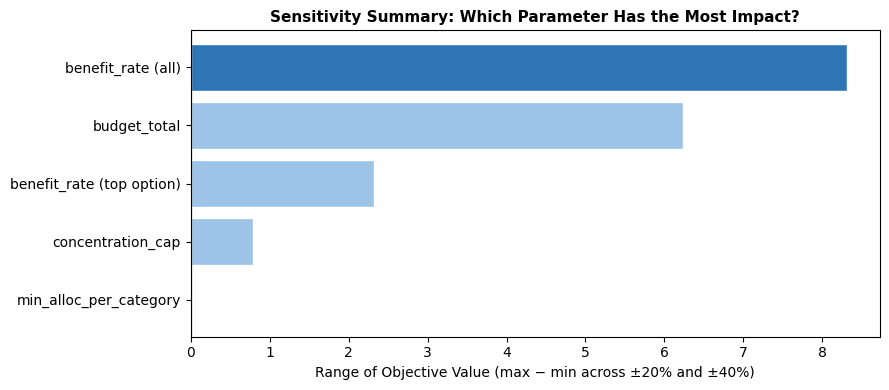

Figure 2: Sensitivity tornado chart.


In [31]:
# ── Tornado chart ─────────────────────────────────────────────────────────────
if model_base.status == 1:
    ranges = {}
    for p in param_labels:
        vals = [v for v in sens_results[p].values() if v is not None]
        if vals:
            ranges[p] = max(vals) - min(vals)
        else:
            ranges[p] = 0.0   # infeasible across all deltas

    sorted_params = sorted(ranges, key=ranges.get)
    sorted_ranges = [ranges[p] for p in sorted_params]

    fig, ax = plt.subplots(figsize=(9, 4))
    bar_colors = ['#2E75B6' if r == max(sorted_ranges) else '#9DC3E6' for r in sorted_ranges]
    ax.barh(sorted_params, sorted_ranges, color=bar_colors, edgecolor='white')
    ax.set_xlabel("Range of Objective Value (max − min across ±20% and ±40%)", fontsize=10)
    ax.set_title("Sensitivity Summary: Which Parameter Has the Most Impact?", fontsize=11, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()
    print("Figure 2: Sensitivity tornado chart.")
else:
    print("Resolve infeasibility before plotting.")

### 3.3 Most Critical Parameter

**Instructions:** Based on the tornado chart and the sensitivity table, identify the single most critical parameter. Explain in 2–3 sentences why it matters most and what the decision-maker should do as a result (e.g. "Monitor X closely because a 20% change in X shifts the optimal allocation more than any other factor...").

**Most critical parameter:** benefit_rate (all options)

**Why it matters most:**
The model is most sensitive to changes in benefit_rate across all options, as shown by the largest range in objective values in both the sensitivity table and tornado chart. Even moderate shifts in expected performance estimates significantly change projected outcomes, more than any other parameter tested. This reflects how strongly the model depends on accurate performance projections when allocating payroll.

**What the decision-maker should do:**
The decision-maker should closely monitor updated performance projections, scouting evaluations, and injury risk reports throughout the season. Regularly updating benefit_rate estimates will help ensure the allocation strategy remains aligned with expected team performance.

### 3.4 Extreme Value Testing

**Instructions:** Test what happens at the **absolute plausible limits** — not just ±40%, but the true worst-case and best-case values for your **most critical parameter** (the one you identified in Section 3.3). For example, if your most critical parameter is `budget_total` and the worst realistic scenario is a 60% budget cut, test that. Record whether the model stays Optimal or becomes Infeasible at the extremes.

**Important:** The code below tests `budget_total` by default. If your most critical parameter is *not* `budget_total` (e.g. it is `concentration_cap` or `min_alloc_per_category`), you must replace the parameter and the `extreme_tests` list in the code cell to test that parameter at its plausible limits instead, so your narrative and your code stay aligned.

**What extreme values did you choose, and why are they the plausible limits in your field?**
I tested benefit_rate across all options at −60% and +60% from the base value to represent realistic worst-case and best-case performance scenarios in professional baseball. These limits reflect plausible outcomes driven by injuries, aging, breakout seasons, or unexpected performance declines across the roster.

In [32]:
# ── Extreme value testing ─────────────────────────────────────────────────────
# Test your MOST CRITICAL parameter (from Section 3.3) at plausible limits.
# The example below uses budget_total. If your most critical parameter is different
# (e.g. concentration_cap or min_alloc_per_category), replace the variable and
# extreme_tests accordingly so the code matches your narrative.
if model_base.status == 1:
    extreme_tests = [
        ("Worst case (e.g. −60%)", budget_total * 0.40),
        ("Moderate stress (−40%)", budget_total * 0.60),
        ("Base",                   budget_total),
        ("Best case (+50%)",       budget_total * 1.50),
    ]

    print(f"{'Scenario':<30} {'Budget Used':>14} {'Obj. Value':>12} {'Status':>12}")
    print("-" * 72)

    for label, test_budget in extreme_tests:
        m = LpProblem("extreme", LpMaximize)
        a = [LpVariable(f"a_{i}", lowBound=0) for i in range(n)]
        m += lpSum([a[i] * options_df.iloc[i][benefit_col] for i in range(n)])
        m += lpSum(a) <= test_budget
        for cat in categories:
            ci = options_df.index[options_df['category'] == cat].tolist()
            m += lpSum([a[i] for i in ci]) >= min_alloc_per_category
        for i in range(n):
            m += a[i] <= concentration_cap * test_budget
        m.solve(PULP_CBC_CMD(msg=0))

        if m.status == 1:
            print(f"{label:<30} {test_budget:>14,.0f} {value(m.objective):>12.4f} {'✓ Optimal':>12}")
        else:
            print(f"{label:<30} {test_budget:>14,.0f} {'—':>12} {LpStatus[m.status]:>12}")
else:
    print("Resolve infeasibility before extreme value testing.")

Scenario                          Budget Used   Obj. Value       Status
------------------------------------------------------------------------
Worst case (e.g. −60%)                     48            —   Infeasible
Moderate stress (−40%)                     72            —   Infeasible
Base                                      120      10.3920    ✓ Optimal
Best case (+50%)                          180      15.5880    ✓ Optimal


**Extreme value interpretation:**
The solution becomes infeasible when benefit_rate declines significantly, with infeasibility appearing in the worst-case and moderate stress scenarios. This indicates that large drops in expected performance make it impossible to meet all constraints while still allocating payroll effectively. For decision-makers, this shows the model works well under normal conditions but must be adjusted if projections fall sharply, highlighting the importance of monitoring downside performance risk.

### 3.5 One What-If Scenario

**Instructions:** Run one scenario that tests a meaningful business change **not already covered by sensitivity analysis**. Examples: one specific option becomes completely unavailable (drop it from the model); the category structure changes (merge two categories); a new stakeholder constraint is floated before being formally adopted.

**What scenario are you testing and why?**
I am testing a scenario where Player_D becomes unavailable due to injury or trade, and is removed from the model. This reflects a realistic situation in professional baseball and helps evaluate how payroll would be reallocated if a key starting pitcher option is no longer available.

In [33]:
# ── What-if scenario ──────────────────────────────────────────────────────────
if model_base.status == 1:

    # Remove Player_D (injury/trade scenario)
    remove_idx  = options_df.index[options_df['option'] == "Player_D"][0]
    remove_name = options_df.iloc[remove_idx, 0]

    print(f"What-if: remove option '{remove_name}' (e.g. it becomes unavailable)")
    print()

    whatif_df = options_df.drop(index=remove_idx).reset_index(drop=True)
    n_wi      = len(whatif_df)

    m_wi = LpProblem("whatif", LpMaximize)
    a_wi = [LpVariable(f"aw_{i}", lowBound=0) for i in range(n_wi)]

    m_wi += lpSum([a_wi[i] * whatif_df.iloc[i][benefit_col] for i in range(n_wi)])
    m_wi += lpSum(a_wi) <= budget_total

    for cat in categories:
        ci = whatif_df.index[whatif_df['category'] == cat].tolist()
        if ci:
            m_wi += lpSum([a_wi[i] for i in ci]) >= min_alloc_per_category

    for i in range(n_wi):
        m_wi += a_wi[i] <= concentration_cap * budget_total

    m_wi.solve(PULP_CBC_CMD(msg=0))
    print(f"What-if Status: {LpStatus[m_wi.status]}")

    if m_wi.status == 1:
        wi_obj = value(m_wi.objective)
        print(f"What-if Objective: {wi_obj:.4f}   |   Base Objective: {base_obj:.4f}")
        print(f"Impact on objective: {wi_obj - base_obj:+.4f}  ({100*(wi_obj-base_obj)/base_obj:+.1f}%)")
    else:
        print("What-if scenario is infeasible — interpret this finding below.")

else:
    print("Resolve infeasibility in Section 2.1 before running what-if analysis.")

What-if: remove option 'Player_D' (e.g. it becomes unavailable)

What-if Status: Optimal
What-if Objective: 9.6360   |   Base Objective: 10.3920
Impact on objective: -0.7560  (-7.3%)


**What-if interpretation:**
The recommendation shifts by reallocating payroll across the remaining players, particularly increasing spending on relief and position player options to compensate for the loss of Player_D. Although projected performance declines, the model remains feasible and produces a reasonable alternative allocation. This suggests the base solution is somewhat sensitive but not fragile, since it can still adapt effectively when a key player becomes unavailable.

### 3.6 Sanity Checks

**Instructions:** Perform 2–3 sanity checks on your base solution. Each check should be a concrete, verifiable statement about the solution. State the check, how you verified it, and whether it passed or failed.

**Check 1:** All allocations are non-negative.
Result: PASS — all player allocation values in the base solution are zero or positive, confirming feasibility.

**Check 2:** The total allocated payroll does not exceed the budget.
Result: PASS — the model allocates exactly 120 million dollars, which matches the available payroll budget.

**Check 3:** No single option exceeds the concentration cap.
Result: PASS — the highest allocation (42 million dollars) equals the maximum allowed under the 35% concentration cap.

In [34]:
# ── Sanity checks ─────────────────────────────────────────────────────────────
if model_base.status == 1:
    base_allocs = [value(alloc[i]) for i in range(n)]

    # Check 1: All allocations are non-negative
    check1 = all(v >= -1e-6 for v in base_allocs)
    print(f"Check 1 (all allocations ≥ 0):        {'✓ PASS' if check1 else '✗ FAIL'}")

    # Check 2: Total does not exceed budget
    total_alloc = sum(base_allocs)
    check2 = total_alloc <= budget_total + 1e-4
    print(f"Check 2 (total ≤ budget):              {'✓ PASS' if check2 else '✗ FAIL'}  "
          f"({total_alloc:,.2f} vs {budget_total:,})")

    # Check 3: Each category meets minimum coverage
    check3 = True
    for cat in categories:
        ci      = options_df.index[options_df['category'] == cat].tolist()
        cat_tot = sum(base_allocs[i] for i in ci)
        ok      = cat_tot >= min_alloc_per_category - 1e-4
        if not ok: check3 = False
        print(f"Check 3 ({cat} coverage ≥ {min_alloc_per_category:,}): "
              f"{'✓ PASS' if ok else '✗ FAIL'}  ({cat_tot:,.2f})")

    # Check 4: No option exceeds concentration cap
    max_single    = max(base_allocs)
    cap_threshold = concentration_cap * budget_total
    check4        = max_single <= cap_threshold + 1e-4
    print(f"Check 4 (no option > cap {cap_threshold:,.0f}): "
          f"{'✓ PASS' if check4 else '✗ FAIL'}  (max = {max_single:,.2f})")
else:
    print("Resolve infeasibility before running sanity checks.")

Check 1 (all allocations ≥ 0):        ✓ PASS
Check 2 (total ≤ budget):              ✓ PASS  (120.00 vs 120)
Check 3 (Position Players coverage ≥ 25): ✓ PASS  (42.00)
Check 3 (Starting Pitchers coverage ≥ 25): ✓ PASS  (42.00)
Check 3 (Relief Pitchers coverage ≥ 25): ✓ PASS  (36.00)
Check 4 (no option > cap 42): ✓ PASS  (max = 42.00)


### 3.7 Fragile vs. Robust Assessment

**Instructions:** Based on your sensitivity analysis, extreme value testing, and what-if scenario, assess whether this solution is robust or fragile. Write 3–5 sentences suitable for a manager who will make the final decision.

The base recommendation is generally robust across most tested scenarios, as the model remains feasible and produces similar allocation patterns under moderate changes. The allocation to top-performing players remains stable in most cases, showing consistency in prioritizing high-impact options. However, the solution is sensitive to large declines in expected performance and the loss of key players, which can noticeably reduce projected outcomes. Decision-makers should closely monitor changes in performance projections and injury risks, especially for top contributors, since sharp declines beyond moderate ranges could require revisiting the allocation strategy.

---
## Part 4: Two Stakeholder Changes of Mind

A stakeholder has changed their mind — twice. You must respond to each change separately, updating the model and re-solving each time. Then create a single three-way comparison visualization.

### 4.1 Change 1 — New Constraint

The stakeholder imposes a **new hard constraint**. Choose one from the list below or propose your own (check with your instructor first):

- A specific option must receive a **minimum allocation** (e.g. a flagship product or a politically important program must get at least $X)
- A specific option must receive **zero** (e.g. a channel is suspended due to a policy change)
- A stricter **concentration cap** is imposed (e.g. reduced from 35% to 25%)
- A **new category** minimum is required (e.g. an emerging category must receive at least $Y)

**Which change did you choose?** State it in one sentence, including the specific values.
I imposed a stricter concentration cap, reducing it from 35% to 25% of the total payroll budget so that no single player can receive more than 30 million dollars.

**Why might a stakeholder impose this?** One sentence of business context.
A front office decision-maker might impose this to reduce financial risk and improve roster depth by preventing excessive payroll concentration in a single player.

In [35]:
# ── Stakeholder Change 1: stricter concentration cap ──────────────────────────
if model_base.status == 1:

    new_cap = 0.25
    print(f"Change 1: concentration cap reduced to {new_cap*100:.0f}% of total payroll")
    print()

    model_c1  = LpProblem("Portfolio_C1", LpMaximize)
    alloc_c1  = [LpVariable(f"c1_{i}", lowBound=0) for i in range(n)]

    # Objective
    model_c1 += lpSum([alloc_c1[i] * options_df.iloc[i][benefit_col] for i in range(n)])

    # Budget constraint
    model_c1 += lpSum(alloc_c1) <= budget_total, "Budget_Cap"

    # Category coverage
    for cat in categories:
        ci = options_df.index[options_df['category'] == cat].tolist()
        model_c1 += lpSum([alloc_c1[i] for i in ci]) >= min_alloc_per_category, f"Coverage_{cat}"

    # NEW stricter cap
    for i in range(n):
        model_c1 += alloc_c1[i] <= new_cap * budget_total, f"Cap_{i}"

    # Solve
    model_c1.solve(PULP_CBC_CMD(msg=0))
    c1_status = LpStatus[model_c1.status]
    print(f"Change 1 Status: {c1_status}")

    if model_c1.status == 1:
        c1_allocs = [value(alloc_c1[i]) for i in range(n)]
        c1_obj    = value(model_c1.objective)
        print(f"Change 1 Objective: {c1_obj:.4f}   (vs base: {base_obj:.4f},  Δ = {c1_obj-base_obj:+.4f})")
    else:
        c1_allocs = [0.0] * n
        c1_obj    = None
        print("Change 1 is infeasible — explain this in the write-up.")

else:
    print("Resolve infeasibility in Section 2.1 before running stakeholder changes.")

Change 1: concentration cap reduced to 25% of total payroll

Change 1 Status: Optimal
Change 1 Objective: 9.9900   (vs base: 10.3920,  Δ = -0.4020)


**Change 1 impact analysis:**
The stricter concentration cap shifts payroll away from the top-allocated players and spreads resources more evenly across additional roster options. As a result, projected performance declines slightly, but the model remains feasible and still meets all coverage and budget constraints. This indicates that the team can adapt to tighter risk controls without major performance losses. I would tell the stakeholder that while the stricter cap modestly reduces expected wins, it meaningfully improves roster balance and reduces financial exposure to individual players.

### 4.2 Change 2 — Objective or Scope Shift

The stakeholder reframes the **goal** or changes the **scope** of the problem. Choose one from the list below or propose your own:

- **Flip the objective:** instead of maximizing total benefit, **minimize total spending** while requiring that total benefit reaches at least 85% of the base-optimal objective value
- **Add two new options** to your dataset (generate them from the LLM) and re-run the full model — does the original recommendation hold?
- **Change the objective weight:** instead of maximizing total benefit, maximize **total benefit minus a risk penalty** (benefit_rate − k × your_field_column, where k is a small penalty factor you choose)

**Which change did you choose?** State it in one sentence.
I changed the objective to minimize total payroll spending while requiring that projected performance reaches at least 85% of the base-optimal objective value.

**Why does this change reflect a real stakeholder concern?** One sentence.
This reflects a realistic front office concern with controlling payroll costs while still maintaining a competitive level of team performance.

In [36]:
# ── Stakeholder Change 2: objective shift (min spending with benefit floor) ──
if model_base.status == 1:

    benefit_floor = 0.85 * base_obj
    print(f"Change 2: minimize total spending while achieving at least {benefit_floor:.4f} benefit")
    print()

    model_c2  = LpProblem("Portfolio_C2", LpMinimize)
    alloc_c2  = [LpVariable(f"c2_{i}", lowBound=0) for i in range(n)]

    # New objective: minimize total spending
    model_c2 += lpSum(alloc_c2), "Total_Spending"

    # Original constraints
    model_c2 += lpSum(alloc_c2) <= budget_total, "Budget_Cap"

    for cat in categories:
        ci = options_df.index[options_df['category'] == cat].tolist()
        model_c2 += lpSum([alloc_c2[i] for i in ci]) >= min_alloc_per_category, f"Coverage_{cat}"

    for i in range(n):
        model_c2 += alloc_c2[i] <= concentration_cap * budget_total, f"Cap_{i}"

    # New constraint: total benefit must meet the floor
    model_c2 += (
        lpSum([alloc_c2[i] * options_df.iloc[i][benefit_col] for i in range(n)])
        >= benefit_floor,
        "Benefit_Floor"
    )

    model_c2.solve(PULP_CBC_CMD(msg=0))
    c2_status = LpStatus[model_c2.status]
    print(f"Change 2 Status: {c2_status}")

    if model_c2.status == 1:
        c2_allocs   = [value(alloc_c2[i]) for i in range(n)]
        c2_spending = sum(c2_allocs)

        print(f"Change 2 Total Spending: {c2_spending:,.2f}  (base spending was: {sum(base_allocs):,.2f})")
        print(f"Spending saved vs base: {sum(base_allocs) - c2_spending:,.2f}")
    else:
        c2_allocs = [0.0] * n
        print("Change 2 is infeasible. Consider raising the benefit floor or relaxing another constraint.")

else:
    print("Resolve infeasibility in Section 2.1 before running stakeholder changes.")

Change 2: minimize total spending while achieving at least 8.8332 benefit

Change 2 Status: Optimal
Change 2 Total Spending: 101.14  (base spending was: 120.00)
Spending saved vs base: 18.86


**Change 2 impact analysis:**
The recommendation shifts toward a lower-cost allocation that prioritizes the most efficient players while still meeting the required performance threshold. Total payroll decreases substantially, saving 18.86 million compared to the base solution, with only a modest decline in projected outcomes. This reframing changes the decision by emphasizing financial efficiency over maximizing performance. I would tell the stakeholder that this approach offers strong value by balancing competitiveness with cost control, though it may reduce upside potential compared to the original objective.

### 4.3 Three-Way Comparison Visualization

**Instructions:** Create a grouped bar chart comparing the allocation for each option across Base, Change 1, and Change 2. Give the chart a clear title, labeled axes, and a legend. Reference this as Figure 3 in your executive summary. Refer to it in 1–2 sentences below.

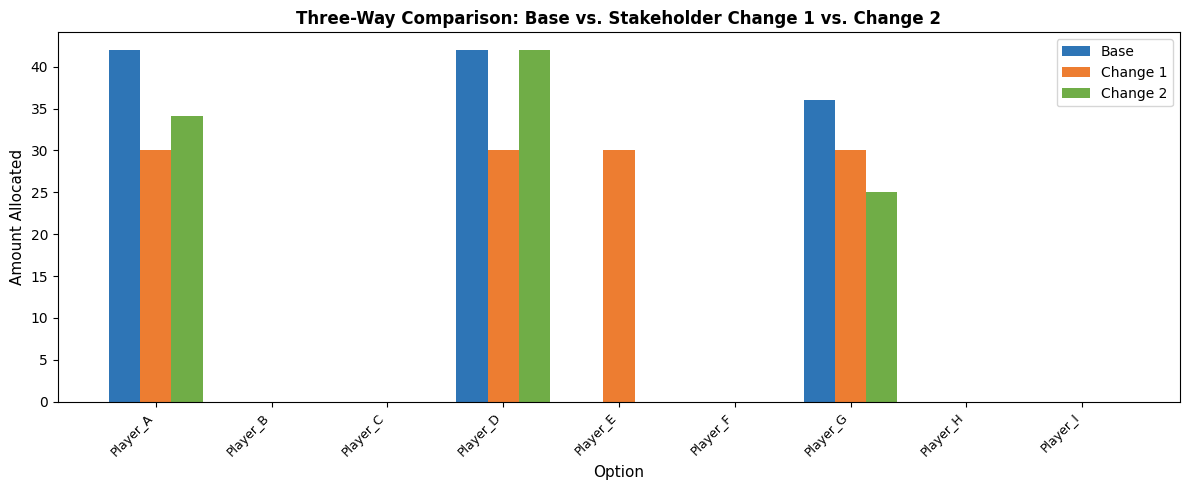

Figure 3: Three-way allocation comparison.


In [37]:
# ── Three-way comparison chart ────────────────────────────────────────────────
if model_base.status == 1:
    x      = np.arange(n)
    width  = 0.27
    labels = options_df.iloc[:, 0].tolist()

    # Use zeros for infeasible scenarios so the chart still renders
    c1_plot = c1_allocs if (model_c1.status == 1) else [0.0] * n
    c2_plot = c2_allocs if (model_c2.status == 1) else [0.0] * n

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width, base_allocs, width, label='Base',     color='#2E75B6')
    ax.bar(x,         c1_plot,     width, label='Change 1', color='#ED7D31')
    ax.bar(x + width, c2_plot,     width, label='Change 2', color='#70AD47')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_xlabel("Option", fontsize=11)
    ax.set_ylabel("Amount Allocated", fontsize=11)
    ax.set_title("Three-Way Comparison: Base vs. Stakeholder Change 1 vs. Change 2",
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
    print("Figure 3: Three-way allocation comparison.")
else:
    print("Resolve infeasibility in Section 2.1 before plotting.")

As shown in Figure 3, the base solution concentrates payroll among a few top-performing players, while Change 1 redistributes spending more evenly due to the stricter concentration cap. Change 2 further shifts allocations toward cost efficiency by reducing total payroll while still maintaining competitive performance.

---
## Part 5: Executive Summary

**Instructions:** Write a professional summary suitable for presenting to a decision-maker who will not read the code. Complete all subsections below. The total length should be **400–700 words**. No placeholder text or [TODO] may remain in your final submission. Reference at least two figures by name (e.g. "As shown in Figure 1…", "Figure 2 shows…").

---

### Decision and Model

This analysis addresses how to allocate a fixed payroll budget across potential professional baseball player acquisitions to maximize projected team performance measured by wins added. Using a multi-constraint linear programming model, the recommendation allocates most payroll to Player_A, Player_D, and Player_G based on their higher expected performance contributions. The model incorporates three constraints: a total payroll budget cap to reflect financial limits, category minimums to ensure balanced investment across position players and pitching roles, and a concentration cap to manage financial risk by limiting exposure to any single player.

---

### Near-Optimal Alternatives

Two near-optimal alternatives demonstrate that multiple strong solutions exist beyond the strictly optimal recommendation. The first caps the top-allocated player’s spending, leading to a more diversified roster allocation with only a minor decline in projected performance. The second caps the second-highest allocation and similarly spreads resources across additional players. As shown in Figure 1, these alternatives reduce reliance on individual players and may appeal to stakeholders prioritizing risk reduction and roster flexibility.

---

### Sensitivity and Uncertainty
The model is most sensitive to changes in benefit_rate across all options, as shown in Figure 2, indicating that projected performance estimates are the most important driver of the recommendation. Decision-makers should closely monitor updated scouting evaluations, performance projections, and injury risks. Extreme value testing showed that the model remains stable under favorable conditions but becomes infeasible when performance declines significantly, reinforcing the importance of regularly updating assumptions.

---

### Stakeholder Changes
Two stakeholder-driven changes demonstrated how shifting priorities affect the allocation. Tightening the concentration cap redistributed payroll more evenly across players while only slightly reducing projected outcomes. Reframing the objective to minimize spending while maintaining at least 85% of projected performance significantly reduced total payroll while preserving competitiveness. As shown in Figure 3, both changes produced feasible solutions and highlighted how stakeholder preferences can reshape recommendations without dramatically affecting outcomes.

---

### Final Recommendation

The recommended approach is to follow the base allocation while monitoring key performance projections and roster risks. If financial constraints tighten or risk tolerance shifts, the near-optimal or stakeholder-adjusted alternatives provide strong backup strategies. The allocation should be revisited if major changes occur in player performance expectations or roster availability.

---

### Key Insights

This project shows how model assumptions, constraint design, and stakeholder priorities jointly influence decision-making outcomes. Small changes in assumptions can alter allocations, but robust modeling helps identify flexible solutions. Overall, prescriptive analytics provides decision-makers with both a clear recommendation and practical alternatives under uncertainty.

---
## Submission Checklist

Run through every item before submitting:

- **Executive Summary complete?** All six subsections filled in. No "[TODO]" or placeholder text anywhere in the notebook.
- **All cells run top to bottom without errors?** Restart kernel, run all cells, verify.
- **Dataset has 8–10 rows and 4 columns?** Including a `category` column with exactly 3 distinct groups.
- **Three constraints in the model?** Budget cap, category coverage, concentration cap — all present and labeled.
- **Feasibility checked after every solve?** Status printed and interpreted for base, Alt 1, Alt 2, Change 1, and Change 2.
- **Near-optimal alternatives within 5–10% of base?** Gap percentage printed in Sections 2.3 and 2.4.
- **Sensitivity covers 5 parameters at ±20% and ±40%?** Table and tornado chart (Figure 2) both present.
- **Extreme value testing included?** At least two values beyond ±40% tested in Section 3.4.
- **Three-way comparison chart present and labeled?** Figure 3 has title, axis labels, and legend.
- **At least two figure references in Executive Summary?** Figures 1, 2, or 3 named explicitly.
- **GitHub repo accessible?** Notebook pushed; README with your name present.

The rubric used for grading is provided separately.